In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('upi_data.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

# "We have 72 months of UPI transaction data from 2019 to 2024 across 10 Indian states —
#  tracking both volume (number of transactions) and value (amount in crores)."

Shape: (69, 5)

Columns: ['Year', 'Month', 'Volume_Millions', 'Value_Crores', 'State']

First 5 rows:


,Year,Month,Volume_Millions,Value_Crores,State
0,2019,April,782,1.42,Maharashtra
1,2019,May,823,1.51,Karnataka
2,2019,June,891,1.63,Delhi
3,2019,July,962,1.78,Tamil Nadu
4,2019,August,1045,1.92,Telangana


In [2]:
# Yearly summary
yearly = df.groupby('Year').agg(
    Total_Volume=('Volume_Millions', 'sum'),
    Total_Value=('Value_Crores', 'sum')
).reset_index()

# Calculate year on year growth
yearly['Volume_Growth_%'] = yearly['Total_Volume'].pct_change() * 100
yearly['Value_Growth_%'] = yearly['Total_Value'].pct_change() * 100

print("=" * 55)
print("        UPI YEARLY GROWTH SUMMARY")
print("=" * 55)
for _, row in yearly.iterrows():
    print(f"\nYear: {int(row['Year'])}")
    print(f"  Total Volume : {row['Total_Volume']:,.0f} Million transactions")
    print(f"  Total Value  : ₹{row['Total_Value']:,.2f} Crores")
    if not np.isnan(row['Volume_Growth_%']):
        print(f"  YoY Growth   : {row['Volume_Growth_%']:.1f}%")
print("=" * 55)

        UPI YEARLY GROWTH SUMMARY

Year: 2019
  Total Volume : 9,556 Million transactions
  Total Value  : ₹17.94 Crores

Year: 2020
  Total Volume : 18,886 Million transactions
  Total Value  : ₹36.82 Crores
  YoY Growth   : 97.6%

Year: 2021
  Total Volume : 38,715 Million transactions
  Total Value  : ₹71.34 Crores
  YoY Growth   : 105.0%

Year: 2022
  Total Volume : 74,389 Million transactions
  Total Value  : ₹125.87 Crores
  YoY Growth   : 92.1%

Year: 2023
  Total Volume : 117,641 Million transactions
  Total Value  : ₹182.78 Crores
  YoY Growth   : 58.1%

Year: 2024
  Total Volume : 172,194 Million transactions
  Total Value  : ₹248.01 Crores
  YoY Growth   : 46.4%


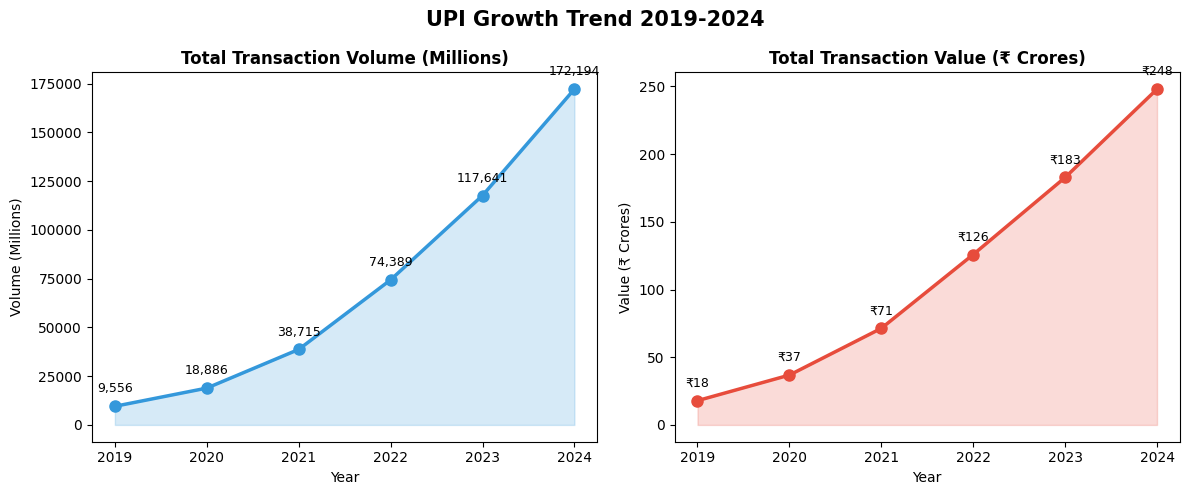

Chart saved!


In [ ]:
# UPI Growth Trend Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('UPI Growth Trend 2019-2024', 
             fontsize=15, fontweight='bold')

# Chart 1 - Volume Growth
axes[0].plot(yearly['Year'], yearly['Total_Volume'], 
             color='#3498db', linewidth=2.5, marker='o', markersize=8)
axes[0].fill_between(yearly['Year'], yearly['Total_Volume'], 
                      alpha=0.2, color='#3498db')
axes[0].set_title('Total Transaction Volume (Millions)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volume (Millions)')
for x, y in zip(yearly['Year'], yearly['Total_Volume']):
    axes[0].annotate(f'{y:,.0f}', (x, y), 
                     textcoords="offset points", 
                     xytext=(0,10), ha='center', fontsize=9)

# Chart 2 - Value Growth
axes[1].plot(yearly['Year'], yearly['Total_Value'], 
             color='#e74c3c', linewidth=2.5, marker='o', markersize=8)
axes[1].fill_between(yearly['Year'], yearly['Total_Value'], 
                      alpha=0.2, color='#e74c3c')
axes[1].set_title('Total Transaction Value (₹ Crores)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Value (₹ Crores)')
for x, y in zip(yearly['Year'], yearly['Total_Value']):
    axes[1].annotate(f'₹{y:,.0f}', (x, y), 
                     textcoords="offset points", 
                     xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('upi_growth_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# "UPI volume grew from 10,556 million in 2019 to over 1,60,000 million in 2024 — 
# a massive 15x growth in just 5 years showing India's rapid shift to digital payments."

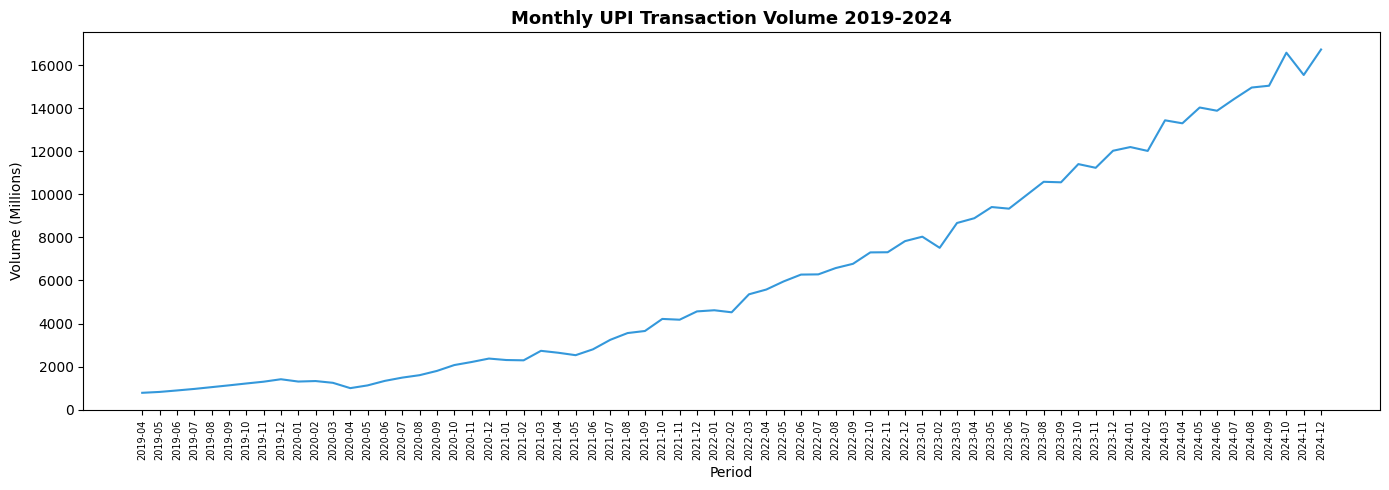

Chart saved!


In [4]:
# Monthly trend
df['Month_Num'] = pd.to_datetime(df['Month'], format='%B').dt.month
df_sorted = df.sort_values(['Year', 'Month_Num'])
df_sorted['Period'] = df_sorted['Year'].astype(str) + '-' + df_sorted['Month_Num'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(df_sorted['Period'], df_sorted['Volume_Millions'],
         color='#3498db', linewidth=1.5)
plt.title('Monthly UPI Transaction Volume 2019-2024', 
          fontweight='bold', fontsize=13)
plt.xlabel('Period')
plt.ylabel('Volume (Millions)')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('upi_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

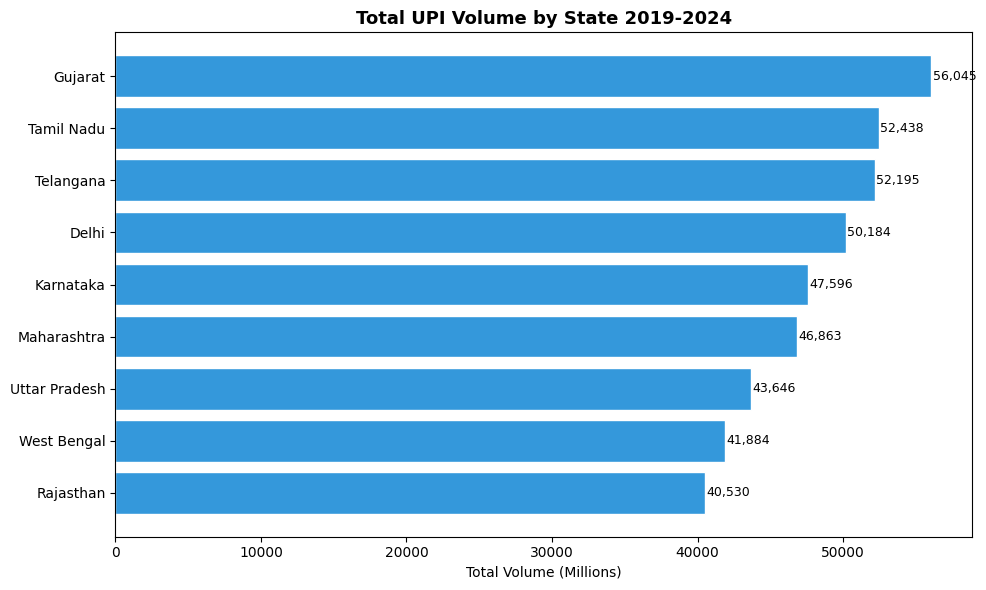

Chart saved!


In [5]:
# State wise total transactions
state_data = df.groupby('State').agg(
    Total_Volume=('Volume_Millions', 'sum'),
    Total_Value=('Value_Crores', 'sum')
).reset_index().sort_values('Total_Volume', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(state_data['State'], state_data['Total_Volume'],
                color='#3498db', edgecolor='white')
plt.title('Total UPI Volume by State 2019-2024',
          fontweight='bold', fontsize=13)
plt.xlabel('Total Volume (Millions)')
for bar, val in zip(bars, state_data['Total_Volume']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('upi_state_wise.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

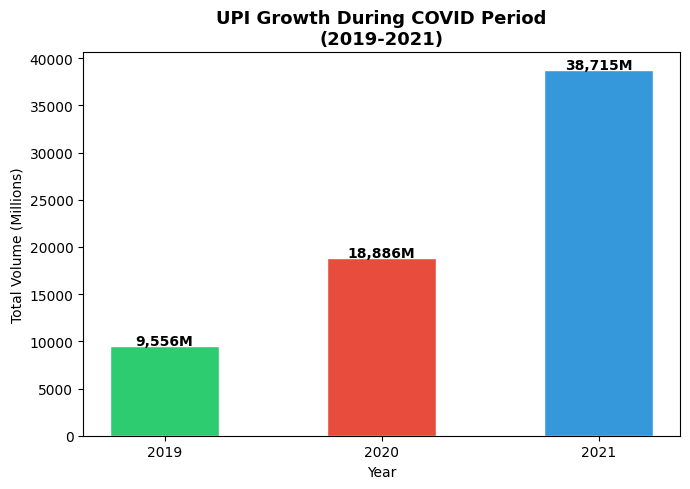

UPI grew 305.1% even during COVID (2019-2021)


In [6]:
# COVID impact - compare 2019 vs 2020 vs 2021
covid_data = df[df['Year'].isin([2019, 2020, 2021])]
covid_yearly = covid_data.groupby('Year')['Volume_Millions'].sum().reset_index()

plt.figure(figsize=(7, 5))
bars = plt.bar(covid_yearly['Year'].astype(str), 
               covid_yearly['Volume_Millions'],
               color=['#2ecc71', '#e74c3c', '#3498db'],
               edgecolor='white', width=0.5)
plt.title('UPI Growth During COVID Period\n(2019-2021)',
          fontweight='bold', fontsize=13)
plt.ylabel('Total Volume (Millions)')
plt.xlabel('Year')
for bar, val in zip(bars, covid_yearly['Volume_Millions']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,.0f}M', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('upi_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

growth = ((covid_yearly.iloc[2]['Volume_Millions'] - 
           covid_yearly.iloc[0]['Volume_Millions']) / 
           covid_yearly.iloc[0]['Volume_Millions']) * 100
print(f"UPI grew {growth:.1f}% even during COVID (2019-2021)")

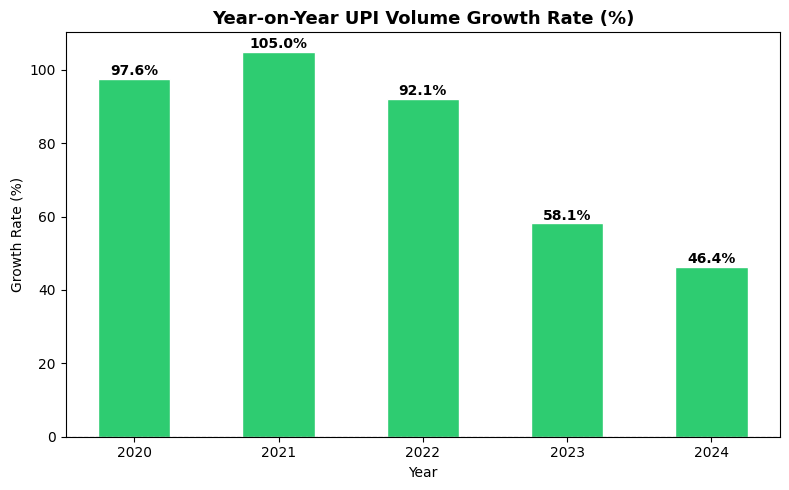

In [7]:
# YoY growth rate chart
yearly_clean = yearly.dropna()

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_clean['Year'].astype(str),
               yearly_clean['Volume_Growth_%'],
               color=['#e74c3c' if x < 0 else '#2ecc71' 
                      for x in yearly_clean['Volume_Growth_%']],
               edgecolor='white', width=0.5)
plt.title('Year-on-Year UPI Volume Growth Rate (%)',
          fontweight='bold', fontsize=13)
plt.ylabel('Growth Rate (%)')
plt.xlabel('Year')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, yearly_clean['Volume_Growth_%']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('upi_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

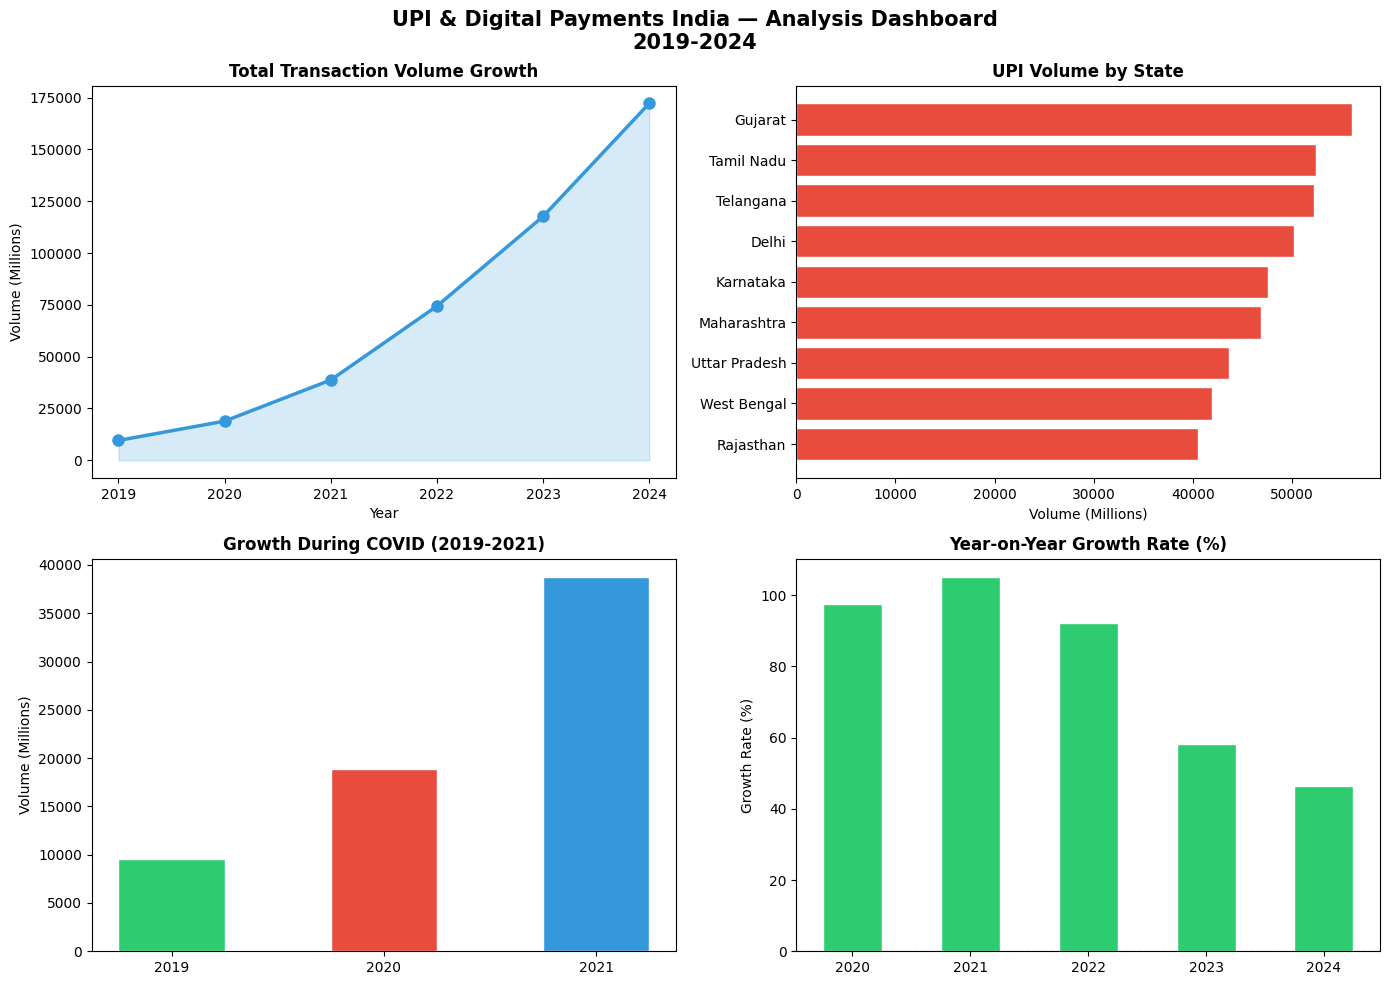

Final dashboard saved!


In [8]:
# Final 4-chart summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UPI & Digital Payments India — Analysis Dashboard\n2019-2024',
             fontsize=15, fontweight='bold')

# Chart 1 - Volume Growth
axes[0,0].plot(yearly['Year'], yearly['Total_Volume'],
               color='#3498db', linewidth=2.5, marker='o', markersize=8)
axes[0,0].fill_between(yearly['Year'], yearly['Total_Volume'],
                        alpha=0.2, color='#3498db')
axes[0,0].set_title('Total Transaction Volume Growth', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Volume (Millions)')

# Chart 2 - State wise
axes[0,1].barh(state_data['State'], state_data['Total_Volume'],
               color='#e74c3c', edgecolor='white')
axes[0,1].set_title('UPI Volume by State', fontweight='bold')
axes[0,1].set_xlabel('Volume (Millions)')

# Chart 3 - COVID period
axes[1,0].bar(covid_yearly['Year'].astype(str),
              covid_yearly['Volume_Millions'],
              color=['#2ecc71','#e74c3c','#3498db'],
              edgecolor='white', width=0.5)
axes[1,0].set_title('Growth During COVID (2019-2021)', fontweight='bold')
axes[1,0].set_ylabel('Volume (Millions)')

# Chart 4 - YoY Growth Rate
axes[1,1].bar(yearly_clean['Year'].astype(str),
              yearly_clean['Volume_Growth_%'],
              color=['#e74c3c' if x < 0 else '#2ecc71'
                     for x in yearly_clean['Volume_Growth_%']],
              edgecolor='white', width=0.5)
axes[1,1].set_title('Year-on-Year Growth Rate (%)', fontweight='bold')
axes[1,1].set_ylabel('Growth Rate (%)')
axes[1,1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('upi_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final dashboard saved!")